# EX.02

# 2-1

In [1]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

In [2]:
!wget --content-disposition https://www.dropbox.com/scl/fi/d709o0nc1t0xdwr76evvi/left02.jpg?rlkey=ukf9m65l7abckz7k3gf07gcwr&dl=0

--2026-03-28 08:18:34--  https://www.dropbox.com/scl/fi/d709o0nc1t0xdwr76evvi/left02.jpg?rlkey=ukf9m65l7abckz7k3gf07gcwr
Resolving www.dropbox.com (www.dropbox.com)... 162.125.4.18, 2620:100:601c:18::a27d:612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.4.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc887fa9db0eea2c394ab7de1bc5.dl.dropboxusercontent.com/cd/0/inline/C9hr1WHpKptzZAouXTHvMNut07lFpzk5gojy4z7RlfejoTEK9So0vU8h2B7BHbui6XVSyGTGKcmuRR7EGnF7HKHBXZMFp7t9kJ9ZJYxsWLONfj3YxbA27g-sLp6EvypVoCaDEpicEjM7EUX7-o24EfeN/file# [following]
--2026-03-28 08:18:35--  https://uc887fa9db0eea2c394ab7de1bc5.dl.dropboxusercontent.com/cd/0/inline/C9hr1WHpKptzZAouXTHvMNut07lFpzk5gojy4z7RlfejoTEK9So0vU8h2B7BHbui6XVSyGTGKcmuRR7EGnF7HKHBXZMFp7t9kJ9ZJYxsWLONfj3YxbA27g-sLp6EvypVoCaDEpicEjM7EUX7-o24EfeN/file
Resolving uc887fa9db0eea2c394ab7de1bc5.dl.dropboxusercontent.com (uc887fa9db0eea2c394ab7de1bc5.dl.dropboxusercontent.com)... 162.125.4.15, 2620:100

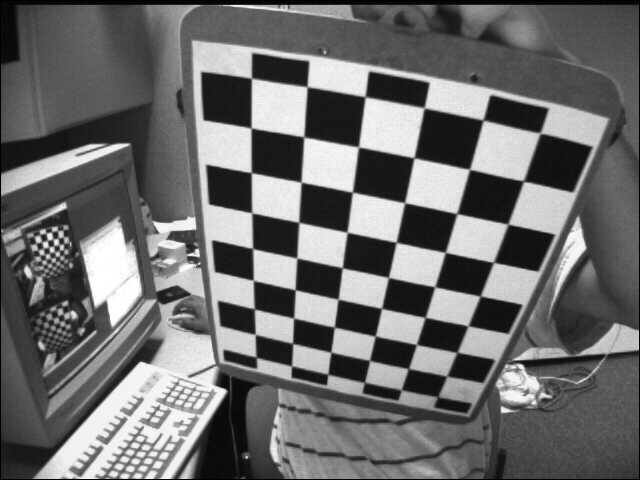

In [3]:
calib_pattern = cv.imread("left02.jpg")
cv2_imshow(calib_pattern)

In [4]:
points = []
points.append((256, 358)) # 1
points.append((252, 78))  # 2
points.append((541, 134)) # 3
points.append((437, 397)) # 4
print(points)


[(256, 358), (252, 78), (541, 134), (437, 397)]


In [5]:
h, w = calib_pattern.shape[:2]
srcPoints = np.array(points, np.float32)
dstPoints = np.array([[100, 100], [w-100, 100], [w-100, h-100], [100, h-100]], np.float32)
print(srcPoints)
print(dstPoints)

[[256. 358.]
 [252.  78.]
 [541. 134.]
 [437. 397.]]
[[100. 100.]
 [540. 100.]
 [540. 380.]
 [100. 380.]]


In [6]:
x  = calib_pattern
H  = cv.getPerspectiveTransform(srcPoints, dstPoints)  # Solving H
# 이미지 좌표 ↔ 평면 좌표 대응으로 Homography H 계산
print(H)

x_ = cv.warpPerspective(x, H, (w, h))  # x_ = Hx
# H를 이용해 이미지를 새로운 평면으로 변환 (warping)

[[ 3.66080959e-01 -1.67664771e+00  5.68477277e+02]
 [ 1.00764804e+00 -1.43627040e-01 -1.44585294e+02]
 [ 3.27607519e-04 -1.29700079e-03  1.00000000e+00]]


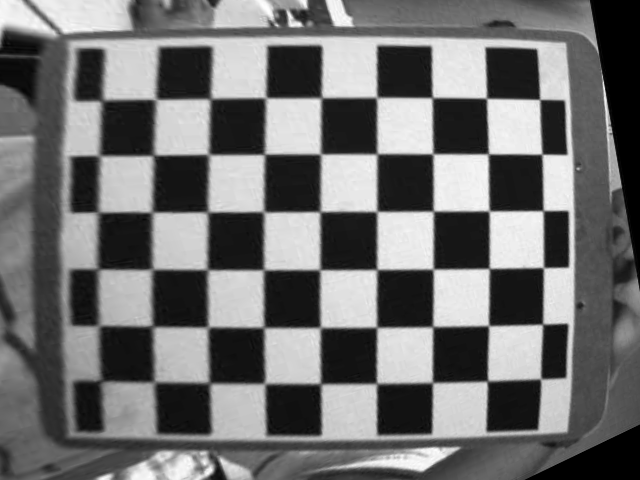

In [7]:
cv2_imshow(x_)

# 2-2

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from numpy import linspace
from glob import glob
from google.colab.patches import cv2_imshow

In [9]:
!wget --content-disposition https://www.dropbox.com/scl/fi/s9yuo7vbbesh0xovbohvp/left01.jpg?rlkey=7qjuuo49li287jsbhsolz2yra&dl=0
!wget --content-disposition https://www.dropbox.com/scl/fi/orihjm6h8erfd57u1ft8v/left03.jpg?rlkey=gvrdixp2gkiiyywdyrobbiw9g&dl=0
!wget --content-disposition https://www.dropbox.com/scl/fi/6334tztfirbx6atat6dzg/left04.jpg?rlkey=dz7hq0lwmt6kkyom4lzn6vdlv&dl=0
!wget --content-disposition https://www.dropbox.com/scl/fi/qmyvi3qx4o3nqrwwc7vt7/left05.jpg?rlkey=4h4x4fk856xix92s70oqpiqnw&dl=0
!wget --content-disposition https://www.dropbox.com/scl/fi/bzzz8ebnr1nxrehkagzdp/left06.jpg?rlkey=1fmngvqua5sowejhxp63uy28t&dl=0
!wget --content-disposition https://www.dropbox.com/scl/fi/7g2a0accdzo5vq02t4kp5/left07.jpg?rlkey=0iwg3vbm9ql1rkgzp2e9fa3ui&dl=0
!wget --content-disposition https://www.dropbox.com/scl/fi/mbzt155teww8ujzkj9i2q/left08.jpg?rlkey=f7foyxmm9cmuzctvxpm2oaihx&dl=0
!wget --content-disposition https://www.dropbox.com/scl/fi/582qjrbz9qcu4dmid2gr1/left09.jpg?rlkey=ave5ecbznqhdbeexbw00tsnxq&dl=0

--2026-03-28 08:18:36--  https://www.dropbox.com/scl/fi/s9yuo7vbbesh0xovbohvp/left01.jpg?rlkey=7qjuuo49li287jsbhsolz2yra
Resolving www.dropbox.com (www.dropbox.com)... 162.125.4.18, 2620:100:601c:18::a27d:612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.4.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uce885c6904de4ed3c9077a455fb.dl.dropboxusercontent.com/cd/0/inline/C9hLcRSwrmeI6hMWaKLso0DZE4zN1m7kZ8yFU0RminxvZOFQgi3P8y5GmA0v-pQGNyOTtfjaRuTNcyYmyNZrv74KzKtWBtUE8tnMgVL25czGQLT7RrctFTrOUPFF4W9Kn1zJsf6b_ycSMDmEZ_OhmEbc/file# [following]
--2026-03-28 08:18:36--  https://uce885c6904de4ed3c9077a455fb.dl.dropboxusercontent.com/cd/0/inline/C9hLcRSwrmeI6hMWaKLso0DZE4zN1m7kZ8yFU0RminxvZOFQgi3P8y5GmA0v-pQGNyOTtfjaRuTNcyYmyNZrv74KzKtWBtUE8tnMgVL25czGQLT7RrctFTrOUPFF4W9Kn1zJsf6b_ycSMDmEZ_OhmEbc/file
Resolving uce885c6904de4ed3c9077a455fb.dl.dropboxusercontent.com (uce885c6904de4ed3c9077a455fb.dl.dropboxusercontent.com)... 162.125.6.15, 2620:100

In [10]:
# load images
img_path = 'left??.jpg'
img_names = glob(img_path)

In [11]:
# pattern
square_size = 1.0

obj_points = []
img_points = []
pattern_size = (9, 6)
pattern_points = np.zeros((np.prod(pattern_size), 3), np.float32)
pattern_points[:, :2] = np.indices(pattern_size).T.reshape(-1, 2)
pattern_points *= square_size
print(pattern_points)

[[0. 0. 0.]
 [1. 0. 0.]
 [2. 0. 0.]
 [3. 0. 0.]
 [4. 0. 0.]
 [5. 0. 0.]
 [6. 0. 0.]
 [7. 0. 0.]
 [8. 0. 0.]
 [0. 1. 0.]
 [1. 1. 0.]
 [2. 1. 0.]
 [3. 1. 0.]
 [4. 1. 0.]
 [5. 1. 0.]
 [6. 1. 0.]
 [7. 1. 0.]
 [8. 1. 0.]
 [0. 2. 0.]
 [1. 2. 0.]
 [2. 2. 0.]
 [3. 2. 0.]
 [4. 2. 0.]
 [5. 2. 0.]
 [6. 2. 0.]
 [7. 2. 0.]
 [8. 2. 0.]
 [0. 3. 0.]
 [1. 3. 0.]
 [2. 3. 0.]
 [3. 3. 0.]
 [4. 3. 0.]
 [5. 3. 0.]
 [6. 3. 0.]
 [7. 3. 0.]
 [8. 3. 0.]
 [0. 4. 0.]
 [1. 4. 0.]
 [2. 4. 0.]
 [3. 4. 0.]
 [4. 4. 0.]
 [5. 4. 0.]
 [6. 4. 0.]
 [7. 4. 0.]
 [8. 4. 0.]
 [0. 5. 0.]
 [1. 5. 0.]
 [2. 5. 0.]
 [3. 5. 0.]
 [4. 5. 0.]
 [5. 5. 0.]
 [6. 5. 0.]
 [7. 5. 0.]
 [8. 5. 0.]]


processing left01.jpg... 


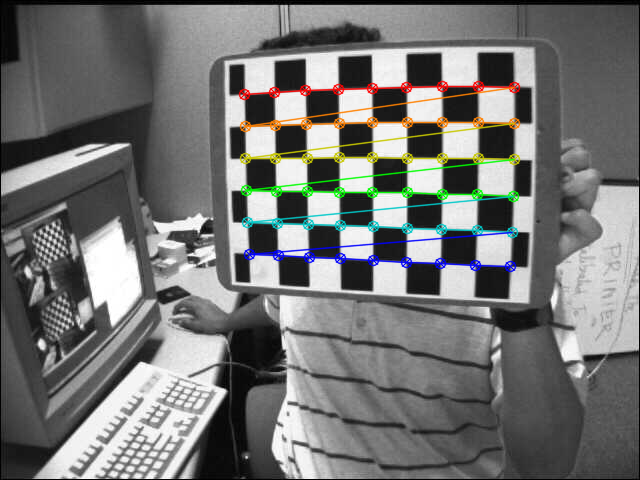

           left01.jpg... OK
processing left09.jpg... 


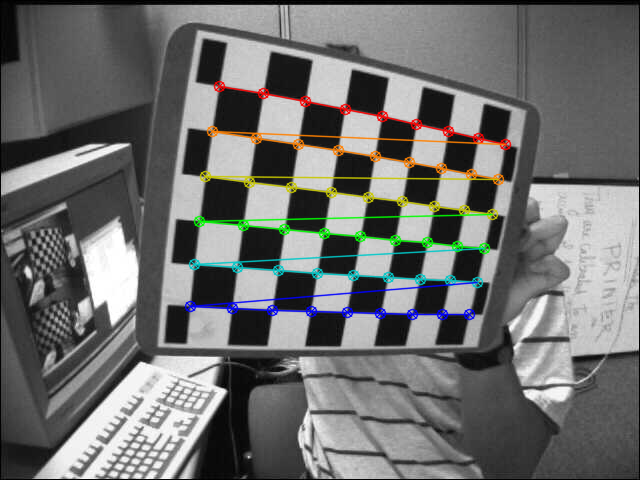

           left09.jpg... OK
processing left01.jpg... 
           left01.jpg... OK
processing left09.jpg... 
           left09.jpg... OK
processing left05.jpg... 
           left05.jpg... OK
processing left04.jpg... 
           left04.jpg... OK
processing left02.jpg... 
           left02.jpg... OK
processing left03.jpg... 
           left03.jpg... OK
processing left07.jpg... 
           left07.jpg... OK
processing left06.jpg... 
           left06.jpg... OK
processing left08.jpg... 
           left08.jpg... OK


In [12]:
# 2D-3D correspondences
def extractCorners(fn, dbg=None):
    print('processing %s... ' % fn)
    img = cv.imread(fn, 0)
    # found: 체스판을 찾았는지 성공 여부. 성공하면 True, 실패하면 False
    # corners: 검출된 코너점들의 2D 좌표(u, v) 뭉치
    found, corners = cv.findChessboardCorners(img, pattern_size)

    # extract corners
    # cv.TERM_CRITERIA_EPS: 오차가 충분히 작아지면 정지
    # cv.TERM_CRITERIA_COUNT: 정해진 횟수만큼 반복하면 정지
    term = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_COUNT, 30, 0.1)
    # cv.cornerSubPix: 좌표를 실수 단위로 정밀화
    # (5, 5) -> winSize: 코너 주변을 얼마나 넓게 보고 보정할지 결정하는 창 크기
    # (-1, -1) -> zeroZone: 계산에서 제외할 영역의 크
    cv.cornerSubPix(img, corners, (5, 5), (-1, -1), term)
    vis = cv.cvtColor(img, cv.COLOR_GRAY2BGR)
    cv.drawChessboardCorners(vis, pattern_size, corners, found)
    if dbg==1: cv2_imshow(vis)

    print('           %s... OK' % fn)
    return (corners.reshape(-1, 2), pattern_points)

h, w = cv.imread(img_names[0], cv.IMREAD_GRAYSCALE).shape[:2]
extractCorners(img_names[0], True)
extractCorners(img_names[1], True)
chessboards = [extractCorners(fn) for fn in img_names]
for (corners, pattern_points) in chessboards:
    obj_points.append(pattern_points)
    img_points.append(corners)

In [13]:
# camera calibration
# cv.calibrateCamera: 카메라 내부 파라미터(내부(K), 외부(R, t), 왜곡 계수) 구하는 함수
# rms: 재투영 오차 / camera_matrix: 내부 파라미터(K) / dist_coefs: 왜곡 계수
# rvecs / tvecs: 외부 파라미터(R / t)
rms, camera_matrix, dist_coefs, rvecs, tvecs = cv.calibrateCamera(obj_points, img_points, (w, h), None, None)
rvecs = np.array(rvecs)
tvecs = np.array(tvecs)
extrinsics = np.zeros( (9,6), np.float32 )
extrinsics[:,:3] = rvecs.reshape(9,3)
extrinsics[:,3:] = tvecs.reshape(9,3)
print("\nintrinsic(5+5) & extrinsic parameters(6)")
print("camera matrix (fx, fy, skew, cx, cy):\n", camera_matrix)
print("distortion coefficients (k1, k2, p1, p2):\n", dist_coefs[:,0:4])


intrinsic(5+5) & extrinsic parameters(6)
camera matrix (fx, fy, skew, cx, cy):
 [[533.18883636   0.         341.64855963]
 [  0.         533.41811388 235.75635274]
 [  0.           0.           1.        ]]
distortion coefficients (k1, k2, p1, p2):
 [[-2.93555930e-01  1.17232634e-01  1.42612563e-03 -2.90196301e-04]]


In [15]:
rvecs

array([[[ 0.16929417],
        [ 0.27599205],
        [ 0.01341837]],

       [[ 0.20328246],
        [-0.42398015],
        [ 0.13215676]],

       [[-0.29108943],
        [ 0.42896656],
        [ 1.31325538]],

       [[-0.11130416],
        [ 0.23920949],
        [-0.00190476]],

       [[ 0.41917902],
        [ 0.65868522],
        [-1.33613571]],

       [[-0.27669381],
        [ 0.18792382],
        [ 0.35515322]],

       [[ 0.17845836],
        [ 0.3433887 ],
        [ 1.86918705]],

       [[ 0.40709306],
        [ 0.30257496],
        [ 1.64869475]],

       [[-0.09002041],
        [ 0.47973945],
        [ 1.75370066]]])

In [16]:
# camera
# cv.Rodrigues: 회전을 벡터와 행렬 사이에서 변환하는 함수
R, J = cv.Rodrigues(extrinsics[0, 0:3])
print("rotation matrix (3 degree of freedom):\n", R)
print("translation vector (3 degree of freedom):\n", extrinsics[0, 3:])
print("\nre-projection error (root mean square):", rms)

rotation matrix (3 degree of freedom):
 [[ 0.9621571   0.00997344  0.27231285]
 [ 0.03634295  0.9857055  -0.16451117]
 [-0.27006102  0.16818224  0.948041  ]]
translation vector (3 degree of freedom):
 [-2.9901826 -4.362823  15.89494  ]

re-projection error (root mean square): 0.19992039275058393


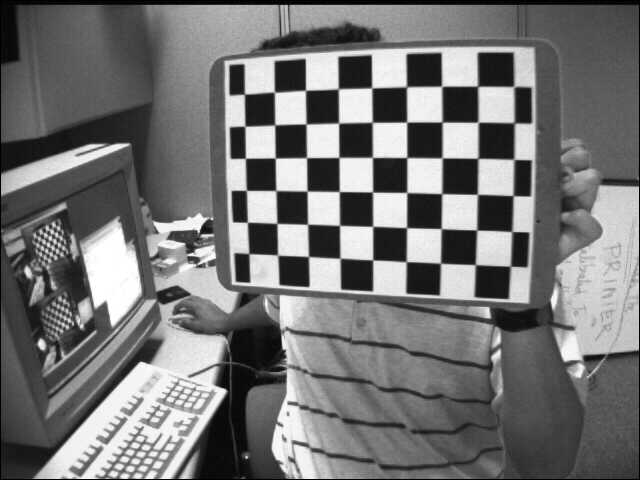

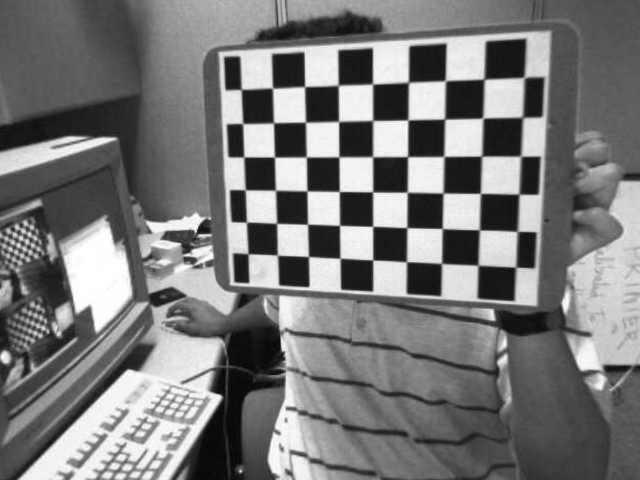

In [17]:
# undistort the image with the calibration
img = cv.imread(img_names[0])
# cv.undistort: 왜곡 계수를 이용해 이미지를 정상적인 기하 구조로 복원
undistorted = cv.undistort(img, camera_matrix, dist_coefs)
cv2_imshow(img)
cv2_imshow(undistorted)

In [18]:
# visualize cameras/patterns (drawing)
def inverse_homogeneoux_matrix(M):
    # 4x4 Homogeneous Matrix의 역행렬을 계산하는 함수
    R = M[0:3, 0:3]
    T = M[0:3, 3]
    M_inv = np.identity(4)
    M_inv[0:3, 0:3] = R.T
    M_inv[0:3, 3] = -(R.T).dot(T)
    return M_inv

def transform_to_matplotlib_frame(cMo, X, inverse=False):
    # OpenCV 좌표계를 Matplotlib 3D 좌표계로 변환하는 함수
    M = np.identity(4)
    M[1,1] = 0
    M[1,2] = 1
    M[2,1] = -1
    M[2,2] = 0
    if inverse:
        return M.dot(inverse_homogeneoux_matrix(cMo).dot(X))
    else:
        return M.dot(cMo.dot(X))

def create_camera_model(camera_matrix, width, height, scale_focal, draw_frame_axis=False):
    # 3D 공간에 그릴 '카메라 피라미드' 모델의 정점들을 생성하는 함수
    fx = camera_matrix[0,0]
    fy = camera_matrix[1,1]
    focal = 2 / (fx + fy)
    f_scale = scale_focal * focal

    # draw image plane
    X_img_plane = np.ones((4,5))
    X_img_plane[0:3,0] = [-width, height, f_scale]
    X_img_plane[0:3,1] = [width, height, f_scale]
    X_img_plane[0:3,2] = [width, -height, f_scale]
    X_img_plane[0:3,3] = [-width, -height, f_scale]
    X_img_plane[0:3,4] = [-width, height, f_scale]

    # draw triangle above the image plane
    X_triangle = np.ones((4,3))
    X_triangle[0:3,0] = [-width, -height, f_scale]
    X_triangle[0:3,1] = [0, -2*height, f_scale]
    X_triangle[0:3,2] = [width, -height, f_scale]

    # draw camera
    X_center1 = np.ones((4,2))
    X_center1[0:3,0] = [0, 0, 0]
    X_center1[0:3,1] = [-width, height, f_scale]

    X_center2 = np.ones((4,2))
    X_center2[0:3,0] = [0, 0, 0]
    X_center2[0:3,1] = [width, height, f_scale]

    X_center3 = np.ones((4,2))
    X_center3[0:3,0] = [0, 0, 0]
    X_center3[0:3,1] = [width, -height, f_scale]

    X_center4 = np.ones((4,2))
    X_center4[0:3,0] = [0, 0, 0]
    X_center4[0:3,1] = [-width, -height, f_scale]

    # draw camera frame axis
    X_frame1 = np.ones((4,2))
    X_frame1[0:3,0] = [0, 0, 0]
    X_frame1[0:3,1] = [f_scale/2, 0, 0]

    X_frame2 = np.ones((4,2))
    X_frame2[0:3,0] = [0, 0, 0]
    X_frame2[0:3,1] = [0, f_scale/2, 0]

    X_frame3 = np.ones((4,2))
    X_frame3[0:3,0] = [0, 0, 0]
    X_frame3[0:3,1] = [0, 0, f_scale/2]

    if draw_frame_axis:
        return [X_img_plane, X_triangle, X_center1, X_center2, X_center3, X_center4, X_frame1, X_frame2, X_frame3]
    else:
        return [X_img_plane, X_triangle, X_center1, X_center2, X_center3, X_center4]

def create_board_model(extrinsics, board_width, board_height, square_size, draw_frame_axis=False):
    # 3D 공간에 그릴 '체스판' 모델의 외곽선 정점들을 생성하는 함수
    width = board_width*square_size
    height = board_height*square_size

    # draw calibration board
    X_board = np.ones((4,5))
    #X_board_cam = np.ones((extrinsics.shape[0],4,5))
    X_board[0:3,0] = [0,0,0]
    X_board[0:3,1] = [width,0,0]
    X_board[0:3,2] = [width,height,0]
    X_board[0:3,3] = [0,height,0]
    X_board[0:3,4] = [0,0,0]

    # draw board frame axis
    X_frame1 = np.ones((4,2))
    X_frame1[0:3,0] = [0, 0, 0]
    X_frame1[0:3,1] = [height/2, 0, 0]

    X_frame2 = np.ones((4,2))
    X_frame2[0:3,0] = [0, 0, 0]
    X_frame2[0:3,1] = [0, height/2, 0]

    X_frame3 = np.ones((4,2))
    X_frame3[0:3,0] = [0, 0, 0]
    X_frame3[0:3,1] = [0, 0, height/2]

    if draw_frame_axis:
        return [X_board, X_frame1, X_frame2, X_frame3]
    else:
        return [X_board]

def draw_camera_boards(ax, camera_matrix, cam_width, cam_height, scale_focal,
                       extrinsics, board_width, board_height, square_size,
                       patternCentric):
    # 최종적으로 Matplotlib 3D 축(ax)에 카메라와 체스판들을 실제로 그려주는 함수
    from matplotlib import cm

    min_values = np.zeros((3,1))
    min_values = np.inf
    max_values = np.zeros((3,1))
    max_values = -np.inf

    if patternCentric:
        X_moving = create_camera_model(camera_matrix, cam_width, cam_height, scale_focal)
        X_static = create_board_model(extrinsics, board_width, board_height, square_size)
    else:
        X_static = create_camera_model(camera_matrix, cam_width, cam_height, scale_focal, True)
        X_moving = create_board_model(extrinsics, board_width, board_height, square_size)

    cm_subsection = linspace(0.0, 1.0, extrinsics.shape[0])
    colors = [ cm.jet(x) for x in cm_subsection ]

    for i in range(len(X_static)):
        X = np.zeros(X_static[i].shape)
        for j in range(X_static[i].shape[1]):
            X[:,j] = transform_to_matplotlib_frame(np.eye(4), X_static[i][:,j])
        ax.plot3D(X[0,:], X[1,:], X[2,:], color='r')
        min_values = np.minimum(min_values, X[0:3,:].min(1))
        max_values = np.maximum(max_values, X[0:3,:].max(1))

    for idx in range(extrinsics.shape[0]):
        R, _ = cv.Rodrigues(extrinsics[idx,0:3])
        cMo = np.eye(4,4)
        cMo[0:3,0:3] = R
        cMo[0:3,3] = extrinsics[idx,3:6]
        for i in range(len(X_moving)):
            X = np.zeros(X_moving[i].shape)
            for j in range(X_moving[i].shape[1]):
                X[0:4,j] = transform_to_matplotlib_frame(cMo, X_moving[i][0:4,j], patternCentric)
            ax.plot3D(X[0,:], X[1,:], X[2,:], color=colors[idx])
            min_values = np.minimum(min_values, X[0:3,:].min(1))
            max_values = np.maximum(max_values, X[0:3,:].max(1))

    return min_values, max_values

In [19]:
# visualize cameras/patterns (parameters)
board_width = int(pattern_size[0])
board_height = int(pattern_size[1])
cam_width = 1
cam_height = 0.75
scale_focal = 1200

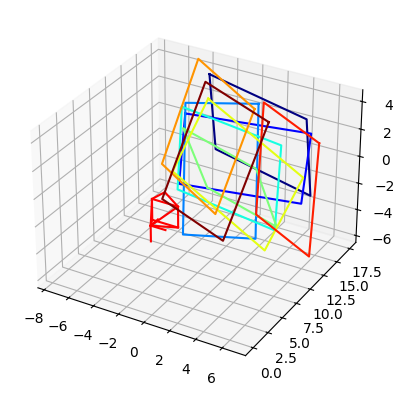

In [20]:
# visualize (patterns)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.set_aspect("auto")
min_values, max_values = draw_camera_boards(ax, camera_matrix, cam_width, cam_height, scale_focal, extrinsics[:,:], board_width, board_height, square_size, False)

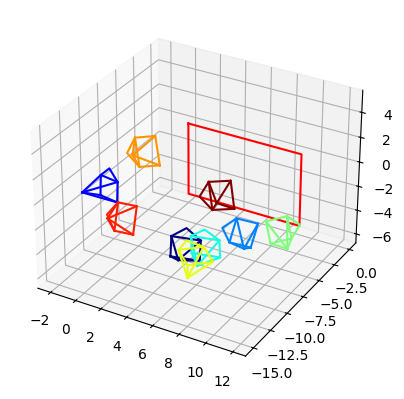

In [21]:
# visualize (cameras)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.set_aspect("auto")
min_values, max_values = draw_camera_boards(ax, camera_matrix, cam_width, cam_height, scale_focal, extrinsics[:,:], board_width, board_height, square_size, True)